# 00 — Groundsource: Preliminary Analysis

**Purpose:** Exploratory data analysis of the raw Groundsource flood event dataset. This notebook
validates the data structure, characterises the distributions of area, duration, and temporal
coverage, and produces global visualisations to confirm the dataset is ready for downstream
processing.

**Input:**
- `groundsource_2026.parquet` — raw flood event records (2,646,302 rows × 5 columns)

**Output:**
- Charts and printed summaries only. No files are saved.

In [1]:
import time
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from shapely import wkb as shapely_wkb

warnings.filterwarnings('ignore')

In [2]:
# --- CONFIGURATION ---

DATA_PATH          = r"D:\Development\RESEARCH\urban_flood_database\Groundsource\groundsource_2026.parquet"
AREA_THRESHOLD_KM2 = 0.25   # minimum plausible flood area (km²)
SAMPLE_SIZE_MAP    = 9_000   # number of events to plot on the global map

## 1. Load and validate dataset structure

In [3]:
t0 = time.time()
df = pd.read_parquet(DATA_PATH)
print(f"Loaded {len(df):,} records in {time.time() - t0:.1f}s")
print(f"\nColumns and dtypes:")
print(df.dtypes)
print(f"\nMissing values per column:")
print(df.isnull().sum())
print(f"\nUnique UUIDs: {df['uuid'].nunique():,}  (should equal row count: {len(df):,})")

Loaded 2,646,302 records in 2.1s

Columns and dtypes:
uuid           object
area_km2      float64
geometry       object
start_date     object
end_date       object
dtype: object

Missing values per column:
uuid          0
area_km2      0
geometry      0
start_date    0
end_date      0
dtype: int64

Unique UUIDs: 2,646,302  (should equal row count: 2,646,302)


## 2. Parse dates and compute duration

In [4]:
df['start_date'] = pd.to_datetime(df['start_date'])
df['end_date']   = pd.to_datetime(df['end_date'])

# Duration: inclusive day count
df['duration_days'] = (df['end_date'] - df['start_date']).dt.days + 1

print("Duration distribution (days):")
dur_counts = df['duration_days'].value_counts().sort_index()
for day, count in dur_counts.items():
    print(f"  {int(day)} day(s) : {count:>10,}  ({count / len(df) * 100:.1f}%)")

print(f"\nDate range: {df['start_date'].min().date()} → {df['start_date'].max().date()}")

Duration distribution (days):
  1 day(s) :  1,449,361  (54.8%)
  2 day(s) :    701,118  (26.5%)
  3 day(s) :    247,964  (9.4%)
  4 day(s) :    117,654  (4.4%)
  5 day(s) :     64,578  (2.4%)
  6 day(s) :     37,076  (1.4%)
  7 day(s) :     28,551  (1.1%)

Date range: 2000-01-01 → 2026-02-03


## 3. Area distribution and threshold analysis

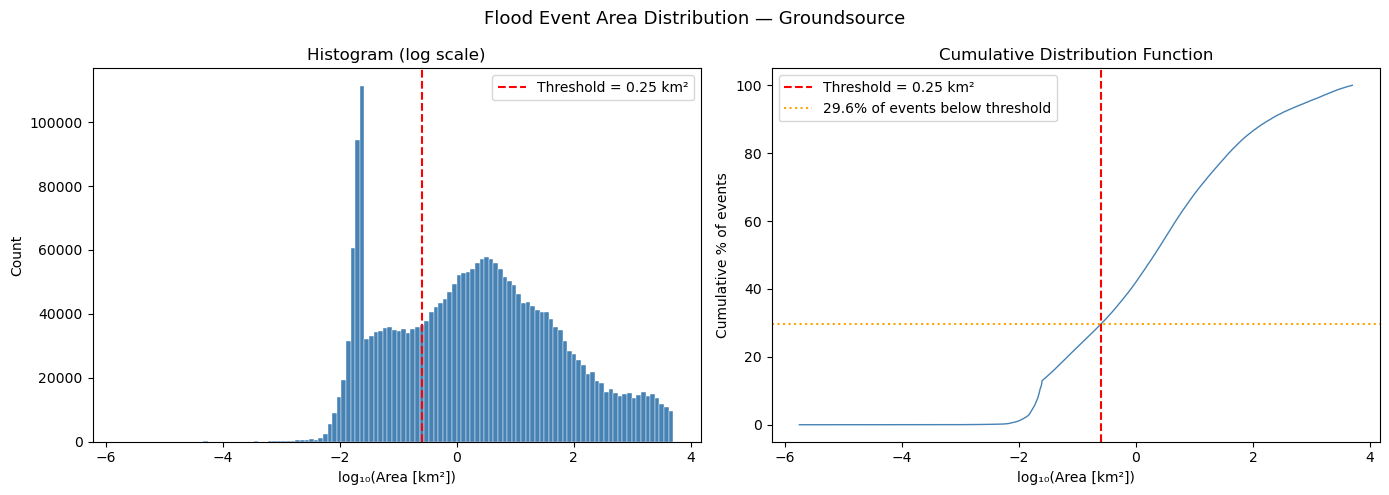

Median area : 2.049 km²
Mean area   : 142.29 km²
Max area    : 4999 km²
Events below 0.25 km² : 29.6%


In [5]:
areas = df['area_km2'].clip(lower=1e-6)
log_areas = np.log10(areas)

sorted_areas = np.sort(areas.values)
cdf = np.arange(1, len(sorted_areas) + 1) / len(sorted_areas)
pct_below = (areas < AREA_THRESHOLD_KM2).mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Flood Event Area Distribution — Groundsource', fontsize=13)

# Histogram
axes[0].hist(log_areas, bins=120, color='steelblue', edgecolor='white', linewidth=0.3)
axes[0].axvline(np.log10(AREA_THRESHOLD_KM2), color='red', linestyle='--',
                label=f'Threshold = {AREA_THRESHOLD_KM2} km²')
axes[0].set_xlabel('log₁₀(Area [km²])')
axes[0].set_ylabel('Count')
axes[0].set_title('Histogram (log scale)')
axes[0].legend()

# CDF
axes[1].plot(np.log10(sorted_areas.clip(min=1e-6)), cdf * 100, color='steelblue', linewidth=1)
axes[1].axvline(np.log10(AREA_THRESHOLD_KM2), color='red', linestyle='--',
                label=f'Threshold = {AREA_THRESHOLD_KM2} km²')
axes[1].axhline(pct_below, color='orange', linestyle=':',
                label=f'{pct_below:.1f}% of events below threshold')
axes[1].set_xlabel('log₁₀(Area [km²])')
axes[1].set_ylabel('Cumulative % of events')
axes[1].set_title('Cumulative Distribution Function')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Median area : {areas.median():.3f} km²")
print(f"Mean area   : {areas.mean():.2f} km²")
print(f"Max area    : {areas.max():.0f} km²")
print(f"Events below {AREA_THRESHOLD_KM2} km² : {pct_below:.1f}%")

## 4. Duration distribution

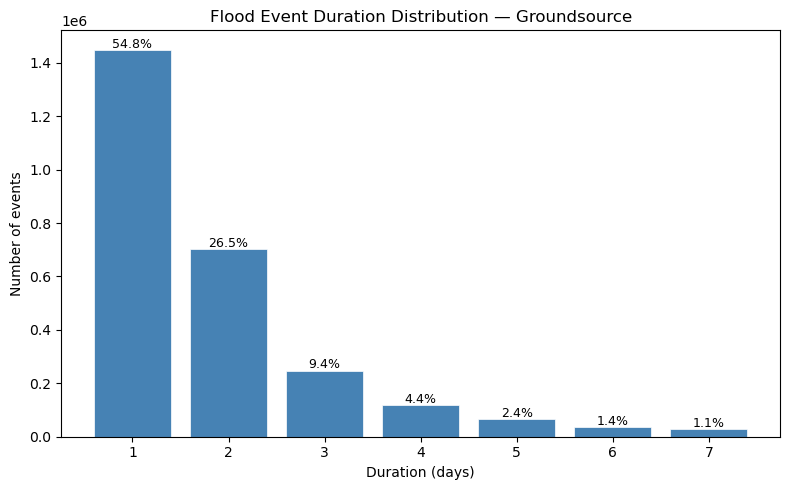

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
dur_counts = df['duration_days'].value_counts().sort_index()
bars = ax.bar(dur_counts.index, dur_counts.values, color='steelblue', edgecolor='white', linewidth=0.5)

for bar, count in zip(bars, dur_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + len(df) * 0.003,
            f'{count / len(df) * 100:.1f}%', ha='center', fontsize=9)

ax.set_xlabel('Duration (days)')
ax.set_ylabel('Number of events')
ax.set_title('Flood Event Duration Distribution — Groundsource')
ax.set_xticks(dur_counts.index)
plt.tight_layout()
plt.show()

## 5. Temporal coverage

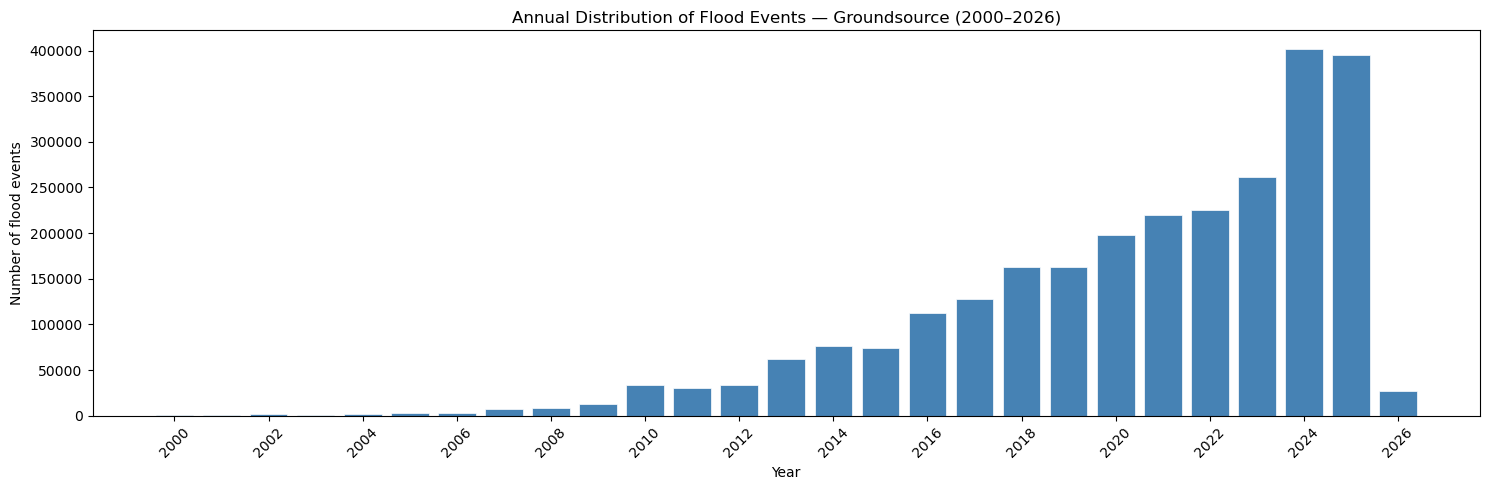

Top 5 years by event count:
start_date
2024    402012
2025    395506
2023    261813
2022    225068
2021    219768
dtype: int64


In [7]:
year_counts = df.groupby(df['start_date'].dt.year).size()

fig, ax = plt.subplots(figsize=(15, 5))
ax.bar(year_counts.index, year_counts.values, color='steelblue', edgecolor='white', linewidth=0.5)
ax.set_xlabel('Year')
ax.set_ylabel('Number of flood events')
ax.set_title('Annual Distribution of Flood Events — Groundsource (2000–2026)')
ax.xaxis.set_major_locator(mticker.MultipleLocator(2))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Top 5 years by event count:")
print(year_counts.sort_values(ascending=False).head())

## 6. Hemisphere and global distribution

In [8]:
# Extract centroids from a random sample for mapping
def decode_centroid(wkb_bytes):
    """Decode WKB geometry bytes and return the (longitude, latitude) of its centroid."""
    try:
        geom = shapely_wkb.loads(wkb_bytes)
        c = geom.centroid
        return c.x, c.y
    except Exception:
        return np.nan, np.nan

print(f"Extracting centroids for {SAMPLE_SIZE_MAP:,} sampled events...")
t1 = time.time()
sample = df.sample(n=min(SAMPLE_SIZE_MAP, len(df)), random_state=42).copy()
coords = sample['geometry'].apply(decode_centroid)
sample['lon'] = coords.apply(lambda x: x[0])
sample['lat'] = coords.apply(lambda x: x[1])
sample = sample.dropna(subset=['lon', 'lat'])
print(f"Done in {time.time() - t1:.1f}s")

# Hemisphere breakdown
nh = (sample['lat'] > 0).mean() * 100
eh = (sample['lon'] > 0).mean() * 100
print(f"Northern hemisphere: {nh:.1f}%   Eastern hemisphere: {eh:.1f}%")

Extracting centroids for 9,000 sampled events...
Done in 0.2s
Northern hemisphere: 79.3%   Eastern hemisphere: 67.2%


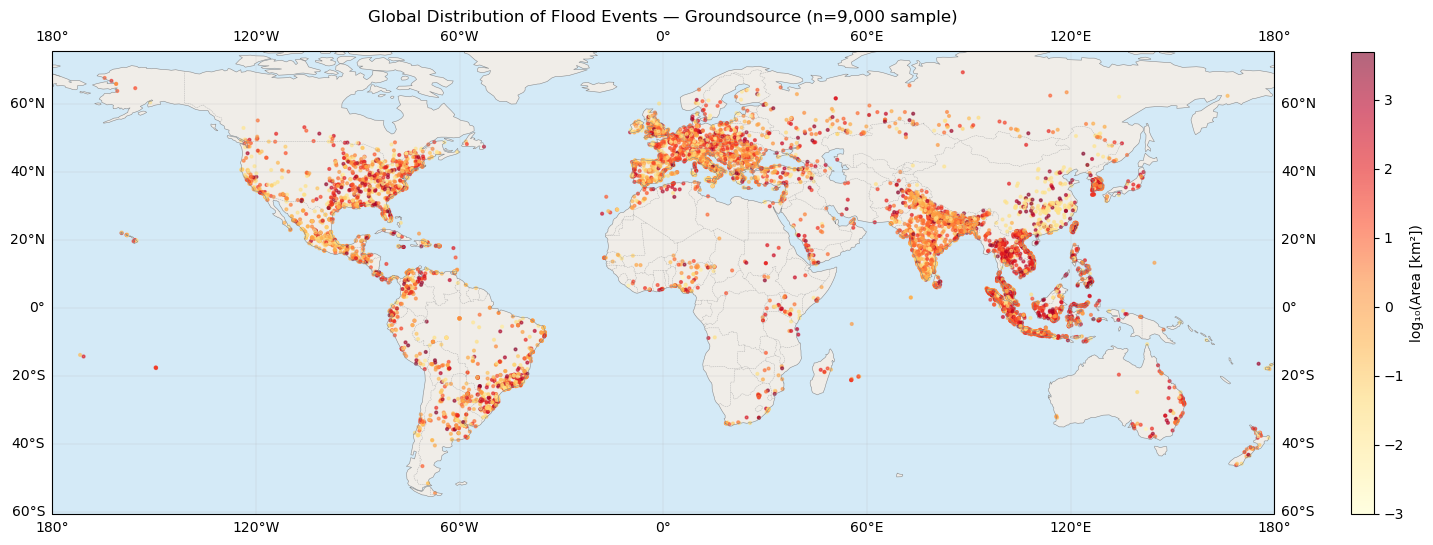

In [9]:
try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature

    fig = plt.figure(figsize=(16, 8))
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND,      facecolor='#f0ede8')
    ax.add_feature(cfeature.OCEAN,     facecolor='#d4eaf7')
    ax.add_feature(cfeature.COASTLINE, linewidth=0.4, edgecolor='#888')
    ax.add_feature(cfeature.BORDERS,   linewidth=0.3, edgecolor='#aaa', linestyle='--')
    ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)

    sc = ax.scatter(
        sample['lon'], sample['lat'],
        c=np.log10(sample['area_km2'].clip(lower=1e-3)),
        cmap='YlOrRd', s=4, alpha=0.6,
        transform=ccrs.PlateCarree()
    )
    plt.colorbar(sc, ax=ax, label='log₁₀(Area [km²])', shrink=0.6, pad=0.05)
    ax.set_title(f'Global Distribution of Flood Events — Groundsource (n={len(sample):,} sample)',
                 fontsize=12)
    plt.tight_layout()
    plt.show()
except ImportError:
    print("Cartopy is not installed — skipping global map.")
    fig, ax = plt.subplots(figsize=(14, 6))
    sc = ax.scatter(sample['lon'], sample['lat'],
                    c=np.log10(sample['area_km2'].clip(lower=1e-3)),
                    cmap='YlOrRd', s=2, alpha=0.5)
    plt.colorbar(sc, label='log₁₀(Area [km²])')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_title('Global Distribution of Flood Events — Groundsource')
    plt.tight_layout()
    plt.show()

## 7. Final summary

In [10]:
print("=" * 55)
print("  GROUNDSOURCE DATASET — PRELIMINARY SUMMARY")
print("=" * 55)
print(f"  Total records        : {len(df):>12,}")
print(f"  Unique UUIDs         : {df['uuid'].nunique():>12,}")
print(f"  Date range           : {df['start_date'].min().date()} → {df['start_date'].max().date()}")
print(f"  Duration mode        : {int(dur_counts.idxmax())} day(s)")
print(f"  Median area          : {df['area_km2'].median():>12.3f} km²")
print(f"  Mean area            : {df['area_km2'].mean():>12.2f} km²")
print(f"  Events < {AREA_THRESHOLD_KM2} km²      : {pct_below:>11.1f}%")
print(f"  Missing values       : {df.isnull().sum().sum():>12}")
print("=" * 55)

  GROUNDSOURCE DATASET — PRELIMINARY SUMMARY
  Total records        :    2,646,302
  Unique UUIDs         :    2,646,302
  Date range           : 2000-01-01 → 2026-02-03
  Duration mode        : 1 day(s)
  Median area          :        2.049 km²
  Mean area            :       142.29 km²
  Events < 0.25 km²      :        29.6%
  Missing values       :            0
